In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Charger le dataset
df = pd.read_csv("data/Affairs.csv")

# Créer la variable cible binaire : tromperie (1 si affairs>0, sinon 0)
df['tromperie'] = (df['affairs'] > 0).astype(int)

# Encodage des variables catégorielles
df['gender'] = LabelEncoder().fit_transform(df['gender'])   # female=0, male=1
df['children'] = LabelEncoder().fit_transform(df['children'])  # no=0, yes=1

# Définir les features pertinentes
features = ['gender', 'age', 'yearsmarried', 'children', 'religiousness',
            'education', 'occupation', 'rating']
X = df[features]
y = df['tromperie']


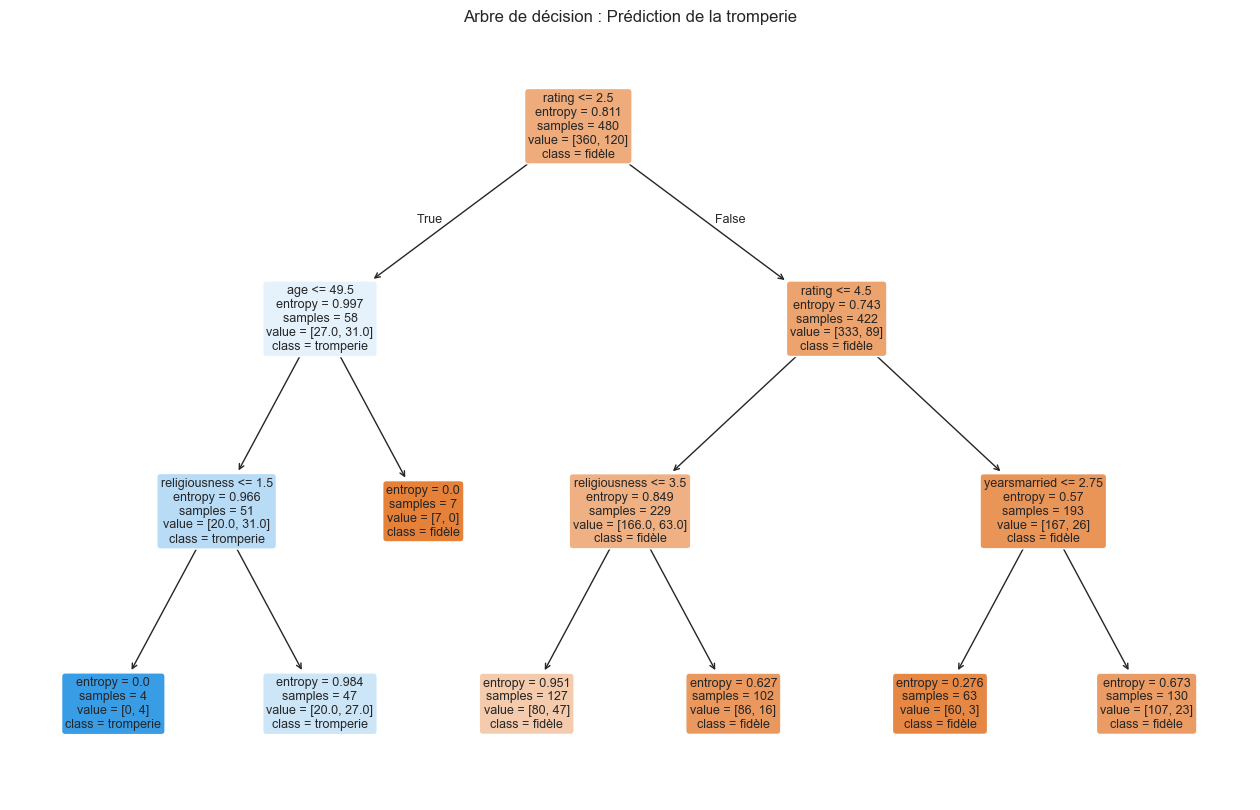

In [5]:
# Découpe train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement du modèle
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Visualisation de l’arbre
plt.figure(figsize=(16, 10))
plot_tree(
    dt,
    feature_names=features,
    class_names=['fidèle', 'tromperie'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Arbre de décision : Prédiction de la tromperie")
plt.show()

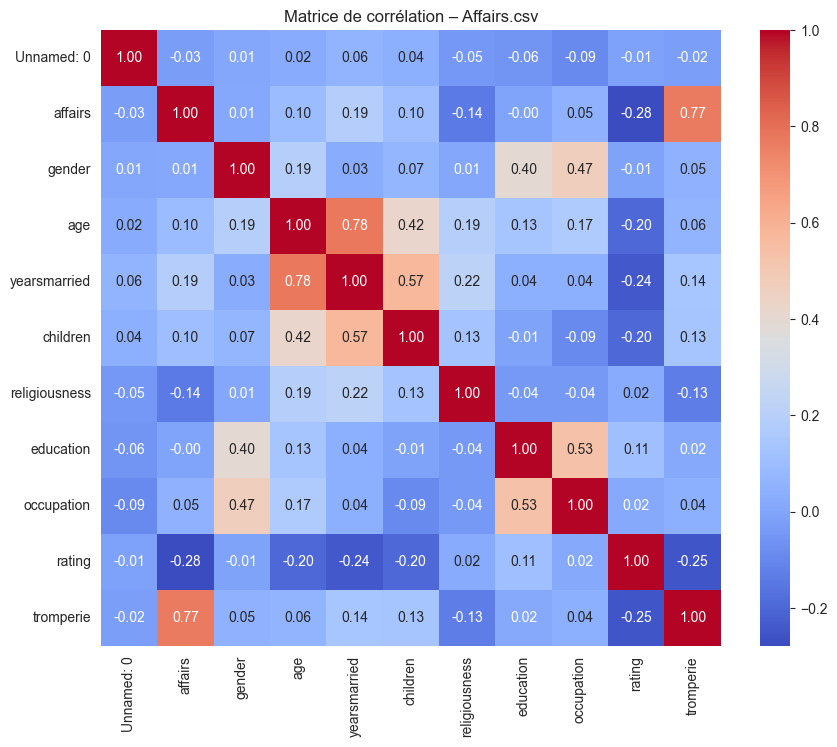

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calcul de la matrice de corrélation
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation – Affairs.csv')
plt.show()


DecisionTreeClassifier(max_depth=5, random_state=42)


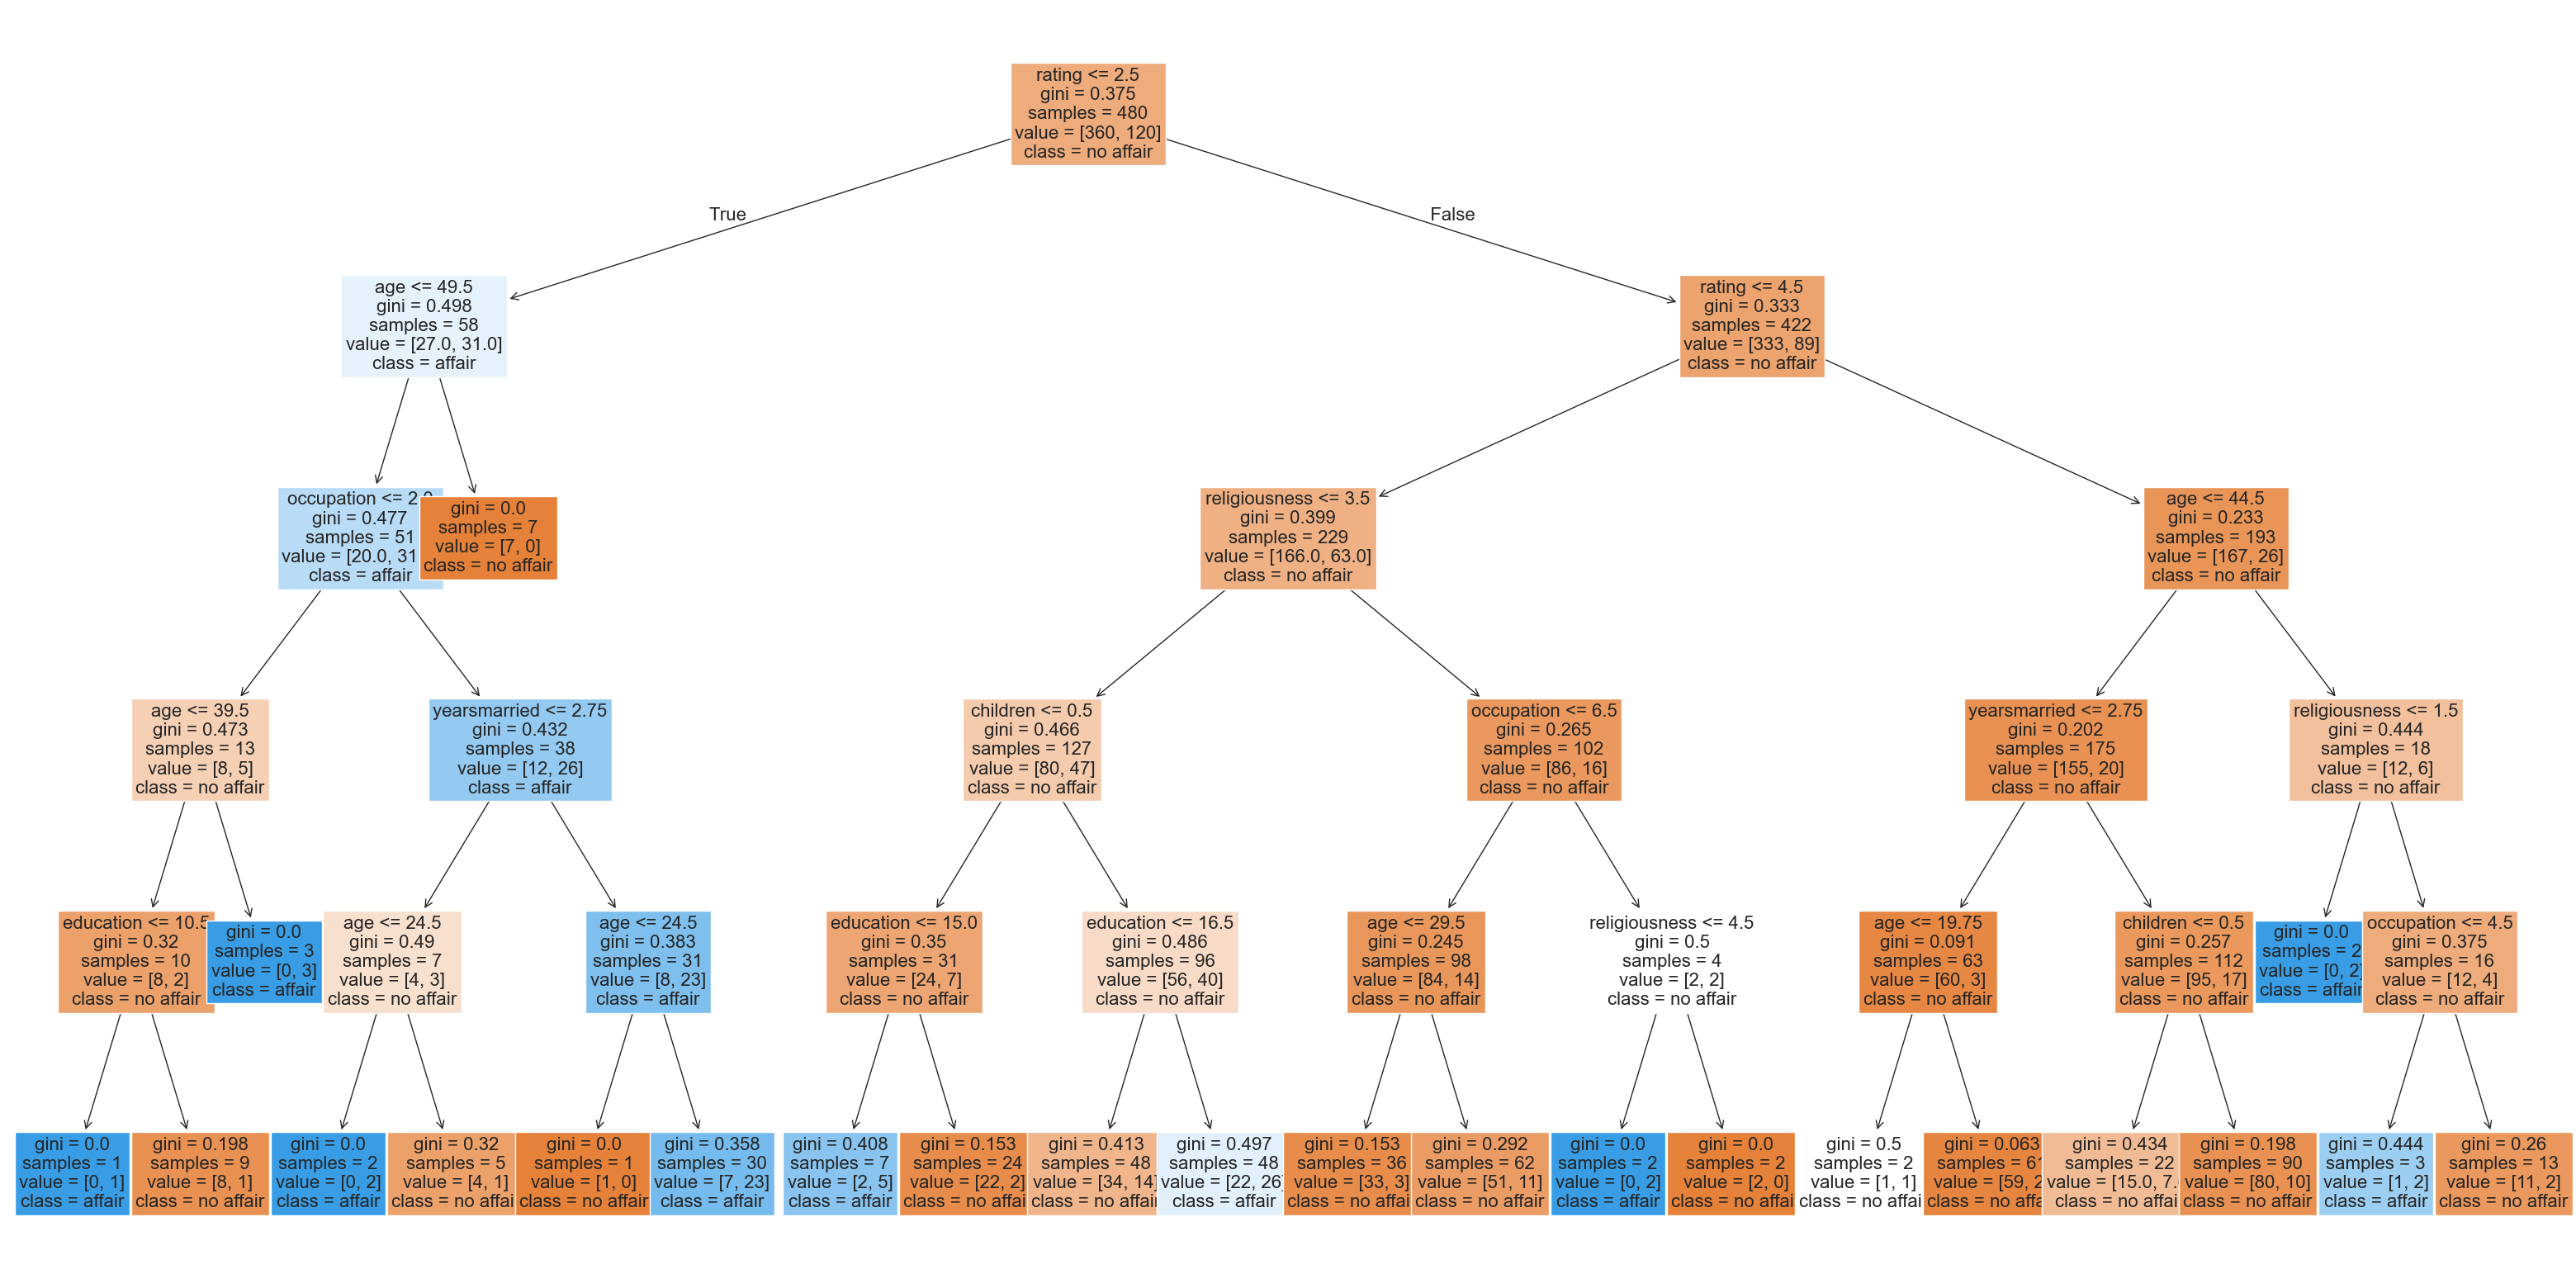

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Charger le jeu de données
df = pd.read_csv("data/Affairs.csv")

# Supprimer la colonne inutile si présente
df=df.drop(df.columns[0],axis=1)
if df.columns[0] == "":
    df = df.drop(df.columns[0], axis=1)

# Encodage des variables catégorielles
df["gender"] = df["gender"].map({"male": 0, "female": 1})
df["children"] = df["children"].map({"no": 0, "yes": 1})

# Définir la cible et les variables explicatives
X = df.drop("affairs", axis=1)
y = df["affairs"].apply(lambda x: 1 if x > 0 else 0)  # 1 = a eu une liaison, 0 = non

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser et entraîner l'arbre de décision
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Visualisation de l'arbre
print(clf)
plt.figure(figsize=(40,20))
plot_tree(clf, feature_names=X.columns, class_names=["no affair", "affair"], filled=True, fontsize=16)
plt.show()